# Compare an online learner to theory

In [65]:
import utils, theory
import numpy as np
import matplotlib.pyplot as plt

P = 100
P_test = 100
n_tasks = 3
N0 = 100
N = 2000
T = 0
sigma = 1
student_type = 'relu'
n_samples = 10

NUM_SEEDS = 5
fixed_w = False
teacher_speed = 1
input_rotation = 0
input_dist = 0
lamb=50

def prepare_student_teacher_data():
    train_x, test_x = utils.generate_rotating_inputs(P, P_test, N0, n_tasks, resample=True, total_angle=input_rotation,
                                                     distance=input_dist, only_test_last=False)
    train_Y, test_Y = utils.get_teacher_labels(train_x, test_x, max_scaler=teacher_speed)
    # train_Y, test_Y = utils.get_linear_teacher_labels(train_x, test_x, max_scaler=teacher_speed)
    return train_x, test_x, train_Y, test_Y


train_x, test_x, train_Y, test_Y = prepare_student_teacher_data()


training_predictions, test_predictions =\
    theory.compute_mean_predictions(train_inputs=train_x, train_targets=train_Y,
                                    w_var=sigma**2, P_test=P_test,
                                    lambda_val=lamb,
                                    test_inputs=test_x,
                                    fix_weights=fixed_w, disable_tqdm=True, student_type=student_type)

Compute predictions using the online learner scheme.

In [66]:

W1 = np.random.normal(0, sigma, (N0, N))
W2 = np.random.normal(lamb / (lamb + sigma ** -2) * W1, np.sqrt((lamb + sigma ** -2) ** -1), (N0, N))
W3 = np.random.normal(lamb / (lamb + sigma ** -2) * W2, np.sqrt((lamb + sigma ** -2) ** -1), (N0, N))
Ws = [W1, W2, W3]
readouts = []

for task_ind in range(n_tasks):
    Phi_t = utils.relu(N0**-0.5 * train_x[task_ind] @ Ws[task_ind])

    if task_ind == 0:
        at_sample, at_mean = theory.sample_at(last_a=None, num_samples=n_samples, target_t=train_Y[task_ind],
                                              features_t=Phi_t, temp=0, lambda_t=lamb, std_t=sigma)
    else:
        at_sample, at_mean = theory.sample_at(last_a=readouts[-1], num_samples=n_samples, target_t=train_Y[task_ind],
                                              features_t=Phi_t, temp=0, lambda_t=lamb, std_t=sigma)
    readouts.append(at_sample)

last_net_prediction_on_first_test = N**-0.5 * utils.relu(N0**-0.5 * test_x[0] @ W3) @ readouts[-1]

In [67]:
last_net_prediction_on_first_test.var(-1).mean(0)

0.11059689826537511

Text(0.5, 1.0, 'predictors after learning 3 tasks, applied on the test set \nlambda=50,P=100,N0=100,N=2000,sigma=1')

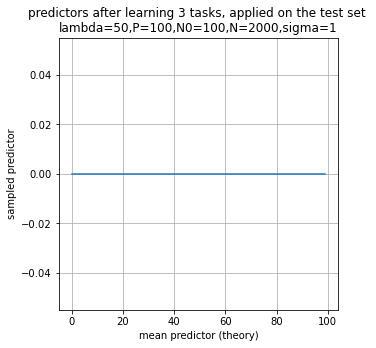

In [63]:
plt.figure(figsize=(5, 5))
plt.plot(last_net_prediction_on_first_test.var(-1))
plt.grid()
plt.xlabel('mean predictor (theory)')
plt.ylabel('sampled predictor')

plt.title('predictors after learning 3 tasks, applied on the test set \n'
          f'lambda={lamb},P={P},N0={N0},N={N},sigma={sigma}')

Text(0.5, 1.0, 'predictors after learning 3 tasks, applied on the test set \nlambda=50,P=100,N0=100,N=2000,sigma=1')

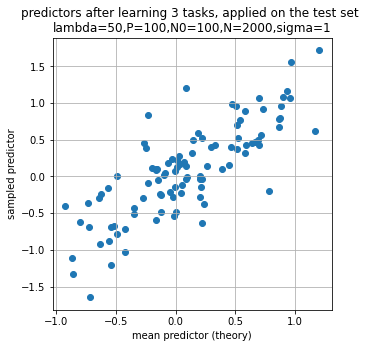

In [62]:
plt.figure(figsize=(5, 5))
plt.scatter(test_predictions[0, 2, :, 0], last_net_prediction_on_first_test.mean(-1))
plt.grid()
plt.xlabel('mean predictor (theory)')
plt.ylabel('sampled predictor')

plt.title('predictors after learning 3 tasks, applied on the test set \n'
          f'lambda={lamb},P={P},N0={N0},N={N},sigma={sigma}')